# Topic 09: Dynamic Mode Decomposition - Supplementary Interactive Material

In [1]:
#Must use Scipi instead of Numpy, as numpy is not compatible with .mat (matlab) file types.

#You will have to download the Data yourself from DMDBOOK Website, once extracted ensure that this next line points to your 
#own "CYLINDER_ALL.mat"

import sys

!{sys.executable} -m pip install pysindy #Install Pysindy

import pysindy as ps
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact
from mpl_toolkits.mplot3d import Axes3D 
from scipy.integrate import solve_ivp

data = sio.loadmat("path/to/your/CYLINDER_ALL.mat")



In [2]:
#Here we can see what Keys the dataset contains
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'UALL', 'UEXTRA', 'VALL', 'VEXTRA', 'VORTALL', 'VORTEXTRA', 'm', 'n', 'nx', 'ny'])


## Vortex Shedding Dataset: Notebook Overview

This notebook analyzes a 2D fluid‐dynamics dataset that exhibits **vortex shedding** behind a cylinder.  
Each snapshot provides:

- Velocity fields  
  $$
  u(x,y,t), \qquad v(x,y,t)
  $$
- **Vorticity field** 
  $$
  \omega(x,y,t)
  $$

---

## 1. Load the Dataset
We load arrays of shape `(nx, ny, nt)` for vorticity

---

## 2. Build Snapshot Matrices for DMD
Each time slice is flattened into a vector and stacked:

- Current-time snapshots:
  $$
  X = [\,x_0,\; x_1,\;\dots,\; x_{t-1}\,]
  $$
- Next-time snapshots:
  $$
  X' = [\,x_1,\; x_2,\;\dots,\; x_t\,]
  $$

Here each vector contains **(u, v, ω)** concatenated.

---

## 3. Perform Dynamic Mode Decomposition
1. Compute SVD:  
   $$
   X = U\Sigma V^*
   $$
2. Truncate to rank \(r\).
3. Build the reduced operator:  
   $$
   \tilde A = U_r^* X' V_r \Sigma_r^{-1}
   $$
4. Eigendecompose:  
   $$
   \tilde A W = W \Lambda
   $$
5. Recover DMD modes:  
   $$
   \Phi = X' V_r \Sigma_r^{-1} W
   $$

---


### Plot An Example Vorticity Snapshot

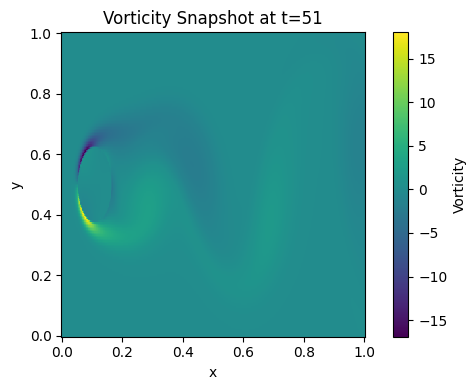

In [3]:
W = data["VORTALL"]         # shape (89351, 151) (we use nx,ny known dimensions, 151 is the number of timesteps)

nx = 449
ny = 199
# ---- Pick timestep ----
k = 51 # choose any 0 <= k < 151

# Extract vectorized vorticity snapshot
w = W[:, k].reshape(nx, ny)   # reshape from (nx*ny,) to (nx, ny)

# Create uniform grid
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)

# Plot 
plt.figure(figsize=(6, 4))
plt.pcolormesh(x, y, w.T, shading='auto', cmap='viridis')
plt.colorbar(label="Vorticity")
plt.gca().set_aspect('equal')
plt.title(f"Vorticity Snapshot at t={k}")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()



### Perform Dynamic Mode Decomposition

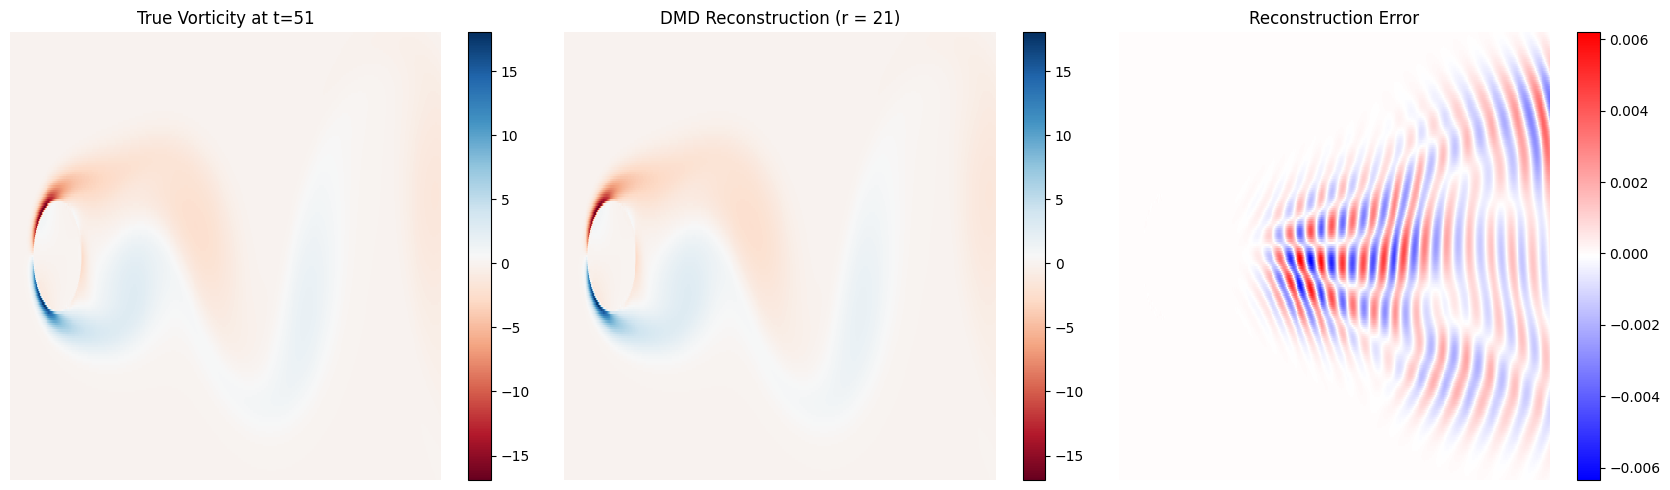

In [4]:
# Build X1, X2
X1 = W[:, :-1]    # columns 0..149
X2 = W[:, 1:]     # columns 1..150

r = 21  

# ---- SVD ----
U, S, Vh = np.linalg.svd(X1, full_matrices=False)
Ur = U[:, :r]
Sr = S[:r]
Vr = Vh.conj().T[:, :r]

# ---- Low-rank operator ----
Atilde = Ur.conj().T @ X2 @ Vr @ np.diag(1/Sr)

# ---- Eigen-decomposition ----
eigvals, Wtilde = np.linalg.eig(Atilde)

# ---- DMD Modes ----
Phi = X2 @ Vr @ np.diag(1/Sr) @ Wtilde   # (nx*ny, r)

# ---- Initial amplitudes ----
b = np.linalg.lstsq(Phi, X1[:,0], rcond=None)[0]


# Reconstruction at time k  


Lambda_k = np.diag(eigvals**k)   # k-th power of eigenvalues
w_recon_vec = Phi @ (Lambda_k @ b)
w_recon = np.real(w_recon_vec.reshape(nx, ny))

# Error field
w_err = w - w_recon


# Plotting

fig, ax = plt.subplots(1, 3, figsize=(17,5))

# True
im0 = ax[0].pcolormesh(x, y, w.T, shading='auto', cmap='RdBu')
ax[0].set_title(f"True Vorticity at t={k}")
ax[0].set_axis_off()
fig.colorbar(im0, ax=ax[0])

# Reconstructed
im1 = ax[1].pcolormesh(x, y, w_recon.T, shading='auto', cmap='RdBu')
ax[1].set_title("DMD Reconstruction (r = 21)")
ax[1].set_axis_off()
fig.colorbar(im1, ax=ax[1])

# Error
im2 = ax[2].pcolormesh(x, y, w_err.T, shading='auto', cmap='bwr')
ax[2].set_title("Reconstruction Error")
ax[2].set_axis_off()
fig.colorbar(im2, ax=ax[2])

plt.tight_layout()
plt.show()

### Visualize Some Modes 

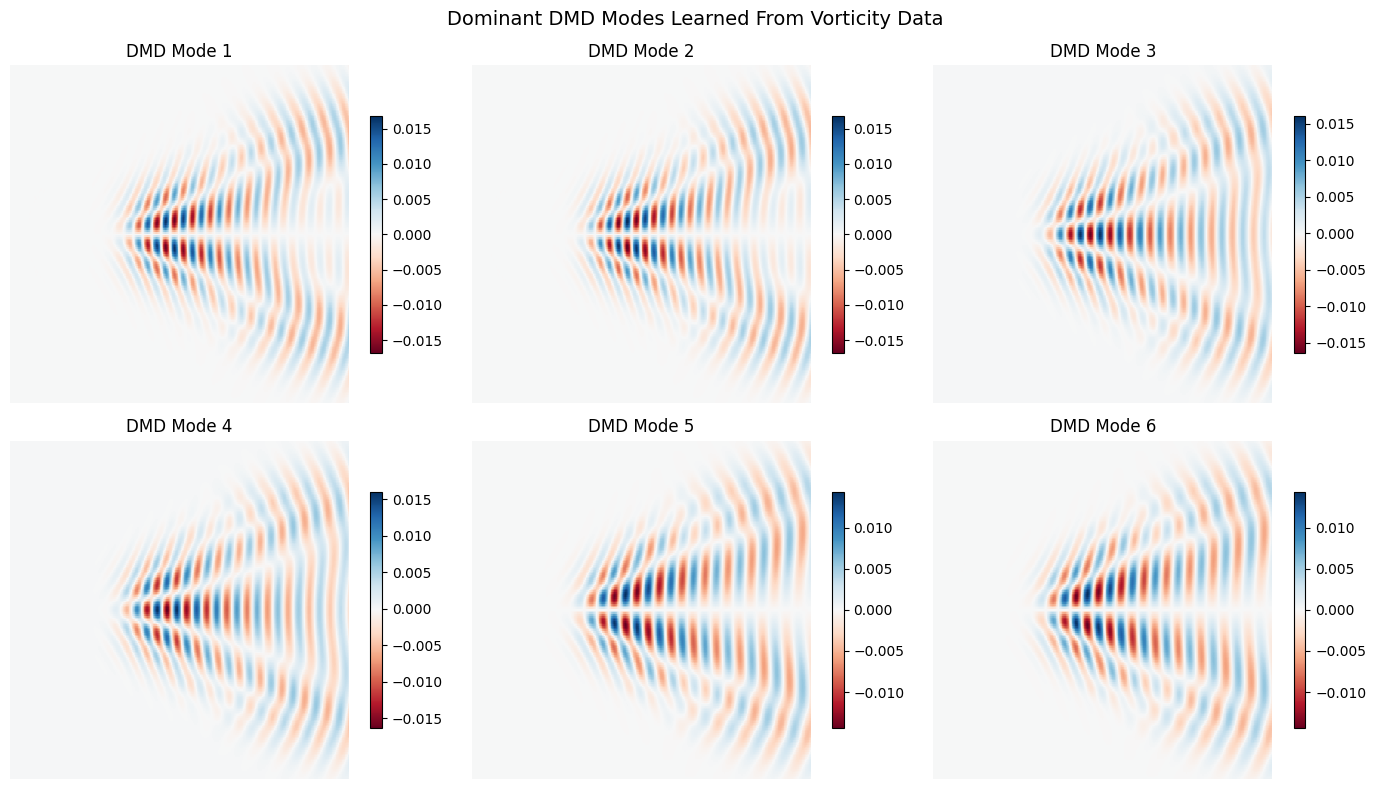

In [5]:
num_modes_to_show = 6  # change to show more

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i in range(num_modes_to_show):
    ax = axes.flat[i]
    
    # Extract and reshape mode (real part)
    mode_i = np.real(Phi[:, i]).reshape(nx, ny)
    
    im = ax.pcolormesh(x, y, mode_i.T, shading='auto', cmap='RdBu')
    ax.set_title(f"DMD Mode {i+1}")
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, shrink=0.7)

plt.suptitle("Dominant DMD Modes Learned From Vorticity Data", fontsize=14)
plt.tight_layout()
plt.show()

## SINDy: Overview

This notebook demonstrates an **intermediate-complexity implementation** of the  
Sparse Identification of Nonlinear Dynamics (SINDy) method.

Fully automated SINDy libraries (such as PySINDy) are highly optimized and stable,  
but they can obscure the core algorithmic ideas.  
Here we adopt a middle approach that exposes the key computational steps without
becoming unnecessarily complicated.

---

## 1. Simulation Data

We begin with a time series of state measurements:

$$X(t) = [\,x(t),\; y(t),\; z(t)\,]$$

sampled at uniform time intervals.  
From these snapshots we aim to identify the governing dynamical system:


$$\dot{X}(t) = f(X(t))$$

---

## 2. Construct the SINDy Library $\Theta(X)$

The SINDy framework approximates the right-hand side as:


$$\dot{X}(t) \approx \Theta(X(t)) \, \Xi,$$


where:

- $\Theta(X)$ is a matrix of candidate nonlinear functions  
- $\Xi$ is a coefficient matrix describing which functions are active  

In this notebook we use PySINDy **only** for the tasks that are tedious but routine:

- numerical differentiation to obtain $\dot{X}$  
- automatic construction of polynomial feature libraries up to a chosen degree  

---

## 3. Sparse Regression (Core SINDy Step)

To determine the governing equations we solve the sparse regression problem:


$$\dot{X} = \Theta(X)\,\Xi$$

subject to the requirement that most entries of $\Xi$ should be zero  

We implement:

1. an initial least-squares fit  
2. iterative thresholding to eliminate small coefficients  
3. re-solving on the remaining active feature set  

This procedure mirrors the sequential thresholded least-squares (STLSQ) algorithm.

---

Data shape X: (10000, 3)
Theta shape: (10000, 20)
Number of features: 20
Ξ shape: (20, 3)

ẋ ≈
  -9.9992 * x
  +9.9992 * y

ẏ ≈
  +27.9924 * x
  -0.9986 * y
  -0.9998 * x z

ż ≈
  -2.6664 * z
  +0.9999 * x y


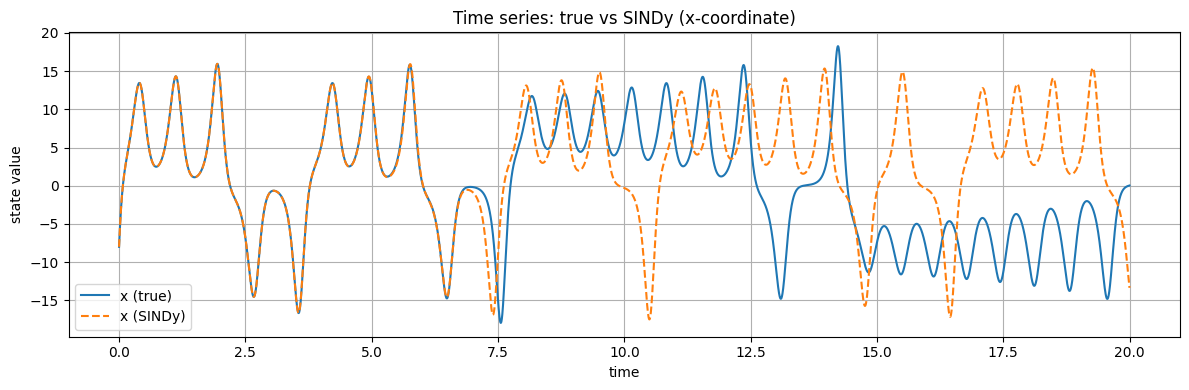

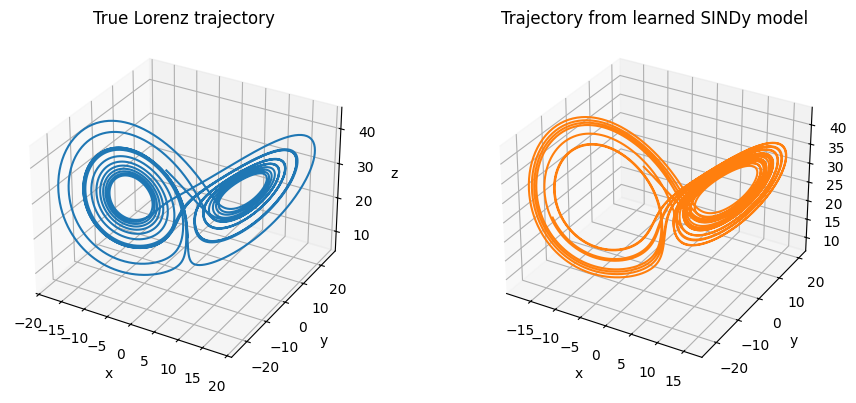

In [6]:



# 1. Define the Lorenz system and generate training data

beta = [10.0, 28.0, 8.0 / 3.0]  # (sigma, rho, beta_param)


def lorenz(t, x):
    """Lorenz right-hand side."""
    sigma, rho, b = beta
    return [
        sigma * (x[1] - x[0]),
        x[0] * (rho - x[2]) - x[1],
        x[0] * x[1] - b * x[2],
    ]


# Time grid for simulation
t_final = 20.0
dt = 0.002
t_eval = np.arange(0, t_final, dt)

# Initial condition
x0 = [-8.0, 8.0, 27.0]

sol = solve_ivp(lorenz, (0, t_final), x0, t_eval=t_eval, rtol=1e-12, atol=1e-12)

X = sol.y.T  # shape (nt, 3) : rows are time, columns are (x, y, z)
t = sol.t

print("Data shape X:", X.shape)


# 2. Use PySINDy for differentiation and feature library


# Numerical differentiation (finite differences)
diff = ps.FiniteDifference(order=2)
dXdt = diff._differentiate(X, t)  # shape (nt, 3)

# Polynomial library Θ(X) (up to degree 3)
lib = ps.PolynomialLibrary(degree=3)
Theta = lib.fit_transform(X)  # shape (nt, n_features)
feature_names = lib.get_feature_names(["x", "y", "z"])

print("Theta shape:", Theta.shape)
print("Number of features:", len(feature_names))



# 3.Sequential Thresholded Least Squares (STLSQ)
def sparse_regression(Theta, dXdt, lam=0.05, n_iter=10):
    """
    Solve dXdt ≈ Θ(X) Ξ using sequential thresholded least squares.

    Parameters
    ----------
    Theta  : (m, p) feature matrix
    dXdt   : (m, n) derivatives
    lam    : float, threshold
    n_iter : int, number of STLSQ passes

    Returns
    -------
    Xi : (p, n) coefficient matrix
    """
    # Initial least squares fit
    Xi = np.linalg.lstsq(Theta, dXdt, rcond=None)[0]  # (p, n)

    for _ in range(n_iter):
        small = np.abs(Xi) < lam
        Xi[small] = 0.0

        # Regress each state derivative using only "large" terms
        for k in range(dXdt.shape[1]):  # loop over ẋ, ẏ, ż
            big = ~small[:, k]
            if np.sum(big) == 0:
                continue
            Xi[big, k] = np.linalg.lstsq(
                Theta[:, big], dXdt[:, k], rcond=None
            )[0]
    return Xi


lambda_ = 0.05  # sparsity knob
    
Xi = sparse_regression(Theta, dXdt, lam=lambda_, n_iter=10)

print("Ξ shape:", Xi.shape)


# 4. Print the discovered equations in a readable form

state_names = ["ẋ", "ẏ", "ż"]

for k, state in enumerate(state_names):
    print(f"\n{state} ≈")
    for j, name in enumerate(feature_names):
        coeff = Xi[j, k]
        if np.abs(coeff) > 1e-6:
            print(f"  {coeff:+.4f} * {name}")


# 5. Define SINDy-based RHS using Θ(X) and Ξ (for comparison)

def sindy_rhs(t, x):
    """
    Use the learned model:
        f(x) ≈ Θ(x) Ξ
    where Θ(x) is one-row evaluation of the feature library.
    """
    x_row = x.reshape(1, -1)           # shape (1, 3)
    Theta_x = lib.transform(x_row)     # shape (1, n_features)
    return (Theta_x @ Xi).ravel()      # shape (3,)


# Integrate the learned SINDy model from the same initial condition
sol_sindy = solve_ivp(
    sindy_rhs,
    (0, t_final),
    x0,
    t_eval=t_eval,
    rtol=1e-10,
    atol=1e-10,
)

X_sindy = sol_sindy.y.T


# 6. PLOTS
plt.figure(figsize=(12, 4))
plt.plot(t, X[:, 0], label="x (true)")
plt.plot(t, X_sindy[:, 0], "--", label="x (SINDy)")
plt.xlabel("time")
plt.ylabel("state value")
plt.title("Time series: true vs SINDy (x-coordinate)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3D trajectory comparison
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot(X[:, 0], X[:, 1], X[:, 2])
ax1.set_title("True Lorenz trajectory")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot(X_sindy[:, 0], X_sindy[:, 1], X_sindy[:, 2], color="C1")
ax2.set_title("Trajectory from learned SINDy model")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")

plt.tight_layout()
plt.show()
